# Modeling: A Minecraft Skin classifier

In this notebook, we will build and train a Convolutional Neural Network (CNN) to automatically detect copyrighted or banned Minecraft character skins (64x64 RGBA images).

**What will happen in this notebook:**
1. **Data Loading & Preprocessing:** We load the image data and set up data augmentation to create more variety for the training process.
2. **Handling Imbalance:** We calculate and apply class weights, as the "normal" skins heavily outnumber the "flagged" skins in our dataset.
3. **Model Training:** We build and compile a binary CNN architecture and train it.
4. **Evaluation:** We evaluate the model's performance, focusing on Precision-Recall metrics and finding the optimal decision threshold to prioritize a high recall.

## Setup & Imports

We use **TensorFlow** for the deep learning pipeline and **scikit-learn** for evaluation metrics.
All random seeds are fixed for reproducibility.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import Sequential, layers
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

/opt/anaconda3/envs/ml-puch/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 3. Central Configuration

**Design decision:** All tunable parameters are defined here in one place.  
This makes the notebook easy to re-run with different settings without hunting through code.  
It also documents every hyperparameter choice explicitly.

In [2]:
# data loading
ROOT = Path("./../")
GOOD_DIR = ROOT / "data" / "skins" / "good_cleaned"  # class 0, uncleaned data set /good
BAD_DIR = ROOT / "data" / "skins" / "bad" / "spiderman_cleaned" # class 1, uncleaned dataset: /spiderman
MODEL_PATH = ROOT / "04_Modeling" / "checkpoint.keras"

# image specs
IMG_SIZE = (64, 64)
N_CHANNELS = 4 # RGBA, transparency is important

# data splits
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# training params
BATCH_SIZE = 32 # small enough for memory, large enough for stable gradients
MAX_EPOCHS = 50 # early stopping will terminate earlier if needed
PATIENCE = 10 # epochs without val_loss improvement before stopping, pretty patient
# learning rate
LR_INIT = 3e-4
LR_FACTOR = 0.5 # halve LR on plateau
LR_PATIENCE = 3 # epochs before LR reduction

# threshold tuning
RECALL_TARGET = 0.95

print(f"Good skins dir: {GOOD_DIR}")
print(f"Bad  skins dir: {BAD_DIR}")
print(f"Image size: {IMG_SIZE}, channels: {N_CHANNELS}")

Good skins dir: ../data/skins/good_cleaned
Bad  skins dir: ../data/skins/bad/spiderman_cleaned
Image size: (64, 64), channels: 4


## Data Loading

We load all `.png` files from `good/` (label 0) and all `.png` files recursively from `bad/` (label 1).  
The `bad/` directory contains one subdirectory per keyword (e.g. `spiderman/`), so we glob recursively.

### Why do we keep the alpha channel?

The Minecraft skin format uses the **alpha channel** as a mask - it encodes which pixels are part of
the skin vs. transparent (unused) regions. Discarding it would lose structural information that could  
help the model distinguish character skins (which often have distinctive transparency patterns).

In [3]:
def find_img_paths(good_dir: Path, bad_dir: Path):
    # Iterate over this subtree and yield all existing files (of any kind, including directories) matching the given relative pattern.
    good_paths = sorted(good_dir.glob("*.png"))
    bad_paths  = sorted(bad_dir.rglob("*.png"))

    paths  = good_paths + bad_paths
    labels = [0] * len(good_paths) + [1] * len(bad_paths)

    print(f"Good skins (class 0): {len(good_paths)}")
    print(f"Bad  skins (class 1): {len(bad_paths)}")
    print(f"Total: {len(paths)}")
    print(f"Class ratio bad/good: {len(bad_paths)/len(good_paths):.3f}")
    return paths, labels

all_paths, all_labels = find_img_paths(GOOD_DIR, BAD_DIR)
all_paths_arr = np.array(all_paths, dtype=object)

Good skins (class 0): 9041
Bad  skins (class 1): 959
Total: 10000
Class ratio bad/good: 0.106


In [4]:
def load_images(paths, img_size=(64, 64)):
    imgs = []
    for p in paths:
        # https://keras.io/api/data_loading/image/
        img = tf.keras.utils.load_img(str(p), color_mode="rgba", target_size=img_size)
        arr = tf.keras.utils.img_to_array(img) / 255.0 # normalize to [0, 1]
        imgs.append(arr)
    return np.array(imgs, dtype=np.float32)

print("Loading images")
X = load_images(all_paths)
y = np.array(all_labels, dtype=np.float32)

print(f"X shape: {X.shape}  →  (samples, height, width, channels)")
print(f"y shape: {y.shape}")
print(f"Pixel value range: [{X.min():.2f}, {X.max():.2f}]")

Loading images
X shape: (10000, 64, 64, 4)  →  (samples, height, width, channels)
y shape: (10000,)
Pixel value range: [0.00, 1.00]


## Exploratory Data Analysis

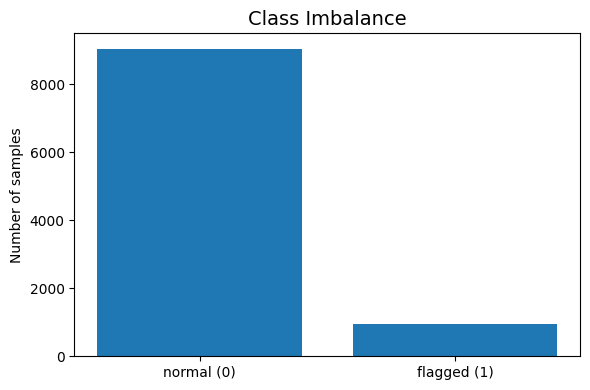

Imbalance ratio (bad/good): 0.11


In [5]:
class_counts = pd.Series(y).value_counts().sort_index()
class_names  = ["normal (0)", "flagged (1)"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_names, class_counts.values)
ax.set_title("Class Imbalance", fontsize=14)
ax.set_ylabel("Number of samples")
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts[1] / class_counts[0]
print(f"Imbalance ratio (bad/good): {imbalance_ratio:.2f}")

Such a ratio needs weighting during training

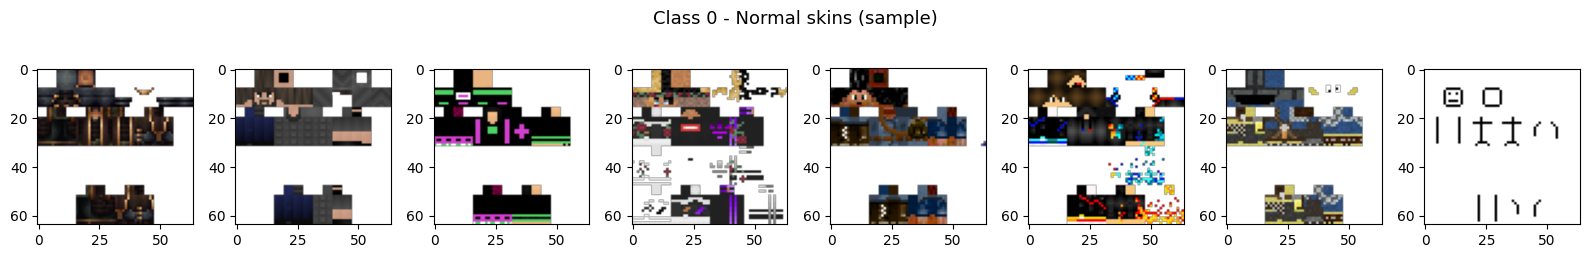

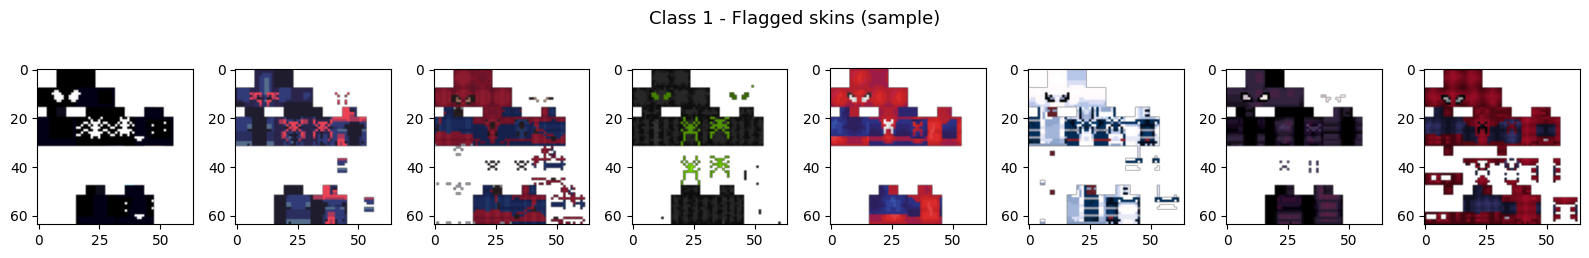

In [6]:
def show_samples(X, y, label, n=8, title=""):
    indices = np.where(y == label)[0]
    chosen  = np.random.choice(indices, size=min(n, len(indices)), replace=False)

    fig, axes = plt.subplots(1, len(chosen), figsize=(2 * len(chosen), 2.5))
    fig.suptitle(title, fontsize=13)
    for ax, idx in zip(axes, chosen):
        ax.imshow(X[idx, :, :, :4])
    plt.tight_layout()
    plt.show()

show_samples(X, y, label=0, n=8, title="Class 0 - Normal skins (sample)")
show_samples(X, y, label=1, n=8, title="Class 1 - Flagged skins (sample)")

A normal looking skin was labeled as spiderman. Apparently the scraped data is not clean enough. We hope that the model can converge and we will check bad false negatives later to swap the labels and re-train

## 6. Train / Validation / Test Split

We use a **stratified** split to ensure the class ratio is preserved in all 3 sets.

In [7]:
# split off test set and preserve it for the end
X_trainval, X_test, y_trainval, y_test, paths_trainval, paths_test = train_test_split(
    X, y, all_paths_arr,
    test_size=TEST_SPLIT,
    stratify=y, # preserve class ratio
    random_state=SEED
)

# split training into train + validation
val_relative = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val, paths_train, paths_val= train_test_split(
    X_trainval, y_trainval, paths_trainval,
    test_size=val_relative,
    stratify=y_trainval,
    random_state=SEED
)

print(f"Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass 1 ratio in train: {y_train.mean():.3f}") # we can just take the mean as we only have two classes
print(f"Class 1 ratio in val: {y_val.mean():.3f}")
print(f"Class 1 ratio in test: {y_test.mean():.3f}")

Train: 7,000 samples (70%)
Val: 1,500 samples (15%)
Test: 1,500 samples (15%)

Class 1 ratio in train: 0.096
Class 1 ratio in val: 0.096
Class 1 ratio in test: 0.096


## 7. Handling Class Imbalance

### Problem

If Class 0 has far more samples than Class 1, a naïve model can achieve high accuracy  
simply by predicting Class 0 for every sample. This is called the **majority-class baseline**.

### Solution: Inverse-frequency class weights
https://www.geeksforgeeks.org/deep-learning/how-to-handle-class-imbalance-in-tensorflow/

We compute weights `w_k = total_samples / (n_classes × count_k)` for each class k.
These weights are passed to `model.fit()` so that errors on the minority class  
count proportionally more in the loss function.  

This is equivalent to **oversampling** the minority class in expectation,  
but requires no data duplication.

In [8]:
n_total = len(y_train)
n_good = int((y_train == 0).sum())
n_bad = int((y_train == 1).sum())
n_classes = 2

# inverse-frequency weighting
class_weights = {
    0: n_total / (n_classes * n_good),
    1: n_total / (n_classes * n_bad),
}

print("Class weights:")
print(class_weights)
print(f"misclassifying a flagged skin costs {class_weights[1]/class_weights[0]}x more than misclassifying a normal skin.")

Class weights:
{0: 0.5530099541791752, 1: 5.216095380029806}
misclassifying a flagged skin costs 9.432190760059612x more than misclassifying a normal skin.


## Data Augmentation

Augmentation artificially increases training diversity, which reduces overfitting and improves generalization to unseen skins.

### What NOT to do with Minecraft skins

Standard augmentations like **horizontal flipping**, **rotation**, or **translation** would break the semantic structure of a Minecraft skin.

The skin format has fixed pixel regions (head: top-left area, body: center, etc.). See below

Shifting the image would move, e.g., the head region into the arm region, creating unwanted inputs that confuse the model.


- **Channel shift / hue phase shifting**: the exact color hue is less class-discriminative
  than the pattern shape

Augmentation is **only applie to the training set** and never to val/test,
because validation and test must reflect the real-world data distribution.

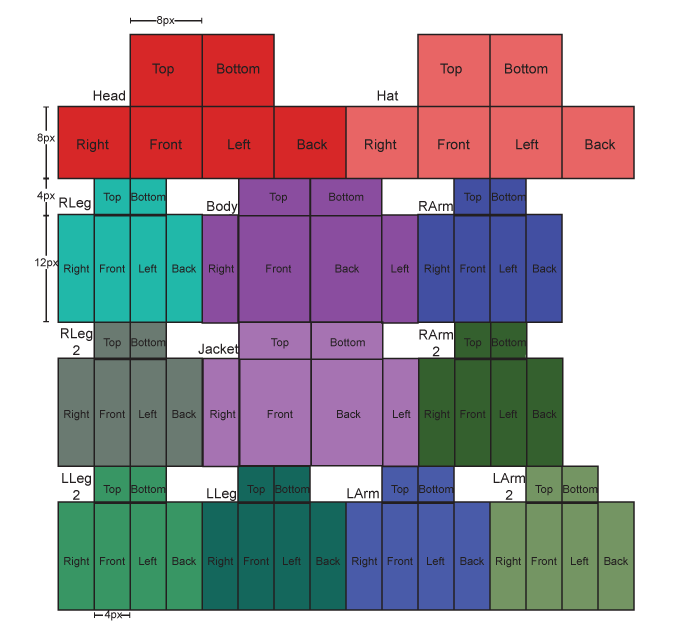

https://www.tensorflow.org/tutorials/images/data_augmentation#data_augmentation_2

In [9]:
from keras.saving import register_keras_serializable
@register_keras_serializable()
class RandomColorShift(layers.Layer):
    def __init__(self, shift_val=0.1, **kwargs):
        super().__init__(**kwargs)
        self.shift_val = shift_val

    def call(self, x, training=None):
        if not training:
            return x  # passthrough at inference
        rgb = x[..., :3]  # mask the R, G, B Values from x
        alpha = x[..., 3:4] # mask alpha, dont change it
        noise = tf.random.uniform(tf.shape(rgb), -self.shift_val, self.shift_val)
        return tf.concat([tf.clip_by_value(rgb + noise, 0.0, 1.0), alpha], axis=-1) # put data with noise together

    def get_config(self):
        config = super().get_config()
        config.update({
            "shift_val": self.shift_val
        })
        return config
        
data_augmentation = tf.keras.Sequential([
    RandomColorShift(0.1),
    layers.GaussianNoise(0.05),  # already respects training flag
])

data_augmentation.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_color_shift              │ ?                      │   0 (unbuilt) │
│ (RandomColorShift)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Baseline Model

Before training a neural network, we establish a **baseline** the simplest possible model.
This serves as a reference: our CNN must clearly outperform it to justify its complexity.

It is literally based on the class imbalance.
If the model predicts better than a class-weighted random guess, it is better

**Majority class baseline:** predict the most frequent class for every input.
It requires no training but reveals the naive upper bound for accuracy on imbalanced data.

In [10]:
majority_class = np.bincount(y_train.astype(int)).argmax()
baseline_preds = np.full(len(y_test), majority_class) # only class 0 guesses
baseline_acc = (baseline_preds == y_test).mean() # but comparing it with the real labels -> high accuracy
baseline_recall = ((baseline_preds == 1) & (y_test == 1)).sum() / (y_test == 1).sum() # recall is extremly bad!

print(f"Majority class: {majority_class}")
print(f"Accuracy: {baseline_acc}")
print(f"Recall (class 1): {baseline_recall}")

Majority class: 0
Accuracy: 0.904
Recall (class 1): 0.0


## CNN

The CNN was adapted from the MNIST CNN example notebook and enhanced for the minecraft skin data

In [11]:
model = Sequential([
        Input(shape=(IMG_SIZE[0], IMG_SIZE[1], N_CHANNELS)),

        data_augmentation,

        # low level patterns
        Conv2D(16, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(16, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.4),

        # mid-level patterns
        Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.4),

        # high level patterns
        Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding="same", activation="relu", kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.4),

        GlobalAveragePooling2D(), # reduce parameters
        Dense(64, activation="relu"),
        Dropout(0.6), # prevent overfit
        Dense(1, activation="sigmoid"), # expansion: softmax for multiple classes
    ], name="minecraft_skin_cnn")

model.summary(expand_nested=True)

Model: "minecraft_skin_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ random_color_shift         │ (None, 64, 64, 4)      │             0 │
│ (RandomColorShift)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ gaussian_noise             │ (None, 64, 64, 4)      │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             

 Total params: 77,345 (302.13 KB)

 Trainable params: 76,897 (300.38 KB)

 Non-trainable params: 448 (1.75 KB)

## Model Compilation

### Metrics tracked during training
- **Precision / Recall** - directly measure false-positive and false-negative rates  
- **Accuracy** - kept for comparison with baseline

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_INIT),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

## Early Stopping and other training callbacks


In [13]:
callbacks = [
    EarlyStopping(
        monitor="val_auc",
        mode="max", # we want to maximize AUC
        patience=PATIENCE,
        restore_best_weights=True, # revert to best epoch after stopping
        verbose=1,
    ),
    ModelCheckpoint( # https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/ModelCheckpoint
        filepath=str(MODEL_PATH),
        monitor="val_auc",
        mode="max", # we want to maximize auc
        save_best_only=True,
        verbose=0,
    ),
]

## Model Training

We pass class weights to every sample to give the minority class proportionally higher loss.
Training will stop automatically when the validation loss stops improving (EarlyStopping).

In [14]:
sample_weights = np.where(y_train == 1, class_weights[1], class_weights[0])
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train, sample_weights))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [15]:
history = model.fit(
    train_dataset,
    epochs=MAX_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1,
)

print(f"Training stopped after {len(history.history['loss'])} epochs.")

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.7451 - auc: 0.8126 - loss: 0.5759 - precision: 0.2376 - recall: 0.7511 - val_accuracy: 0.9040 - val_auc: 0.8327 - val_loss: 0.2956 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.8366 - auc: 0.8896 - loss: 0.4433 - precision: 0.3498 - recall: 0.8212 - val_accuracy: 0.9340 - val_auc: 0.8975 - val_loss: 0.2149 - val_precision: 0.7368 - val_recall: 0.4861
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.8500 - auc: 0.9114 - loss: 0.3994 - precision: 0.3734 - recall: 0.8331 - val_accuracy: 0.9040 - val_auc: 0.9263 - val_loss: 0.2520 - val_precision: 0.5000 - val_recall: 0.7292
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.8709 - auc: 0.9277 - loss: 0.3616 - precision: 0.4156 - recall: 0.8554 - val_accuracy: 0.9147 - val_auc: 0.9375 - val_loss: 0.2303 - val_precision: 0.5392 - val_recall: 0.7639
Epoch 5/50
219/2

## Training Curves
We plot loss and key metrics over epochs to assess:
- Whether the model **converged** (curves flatten)
- Whether there is **overfitting** (train improves, val stagnates or worsens)

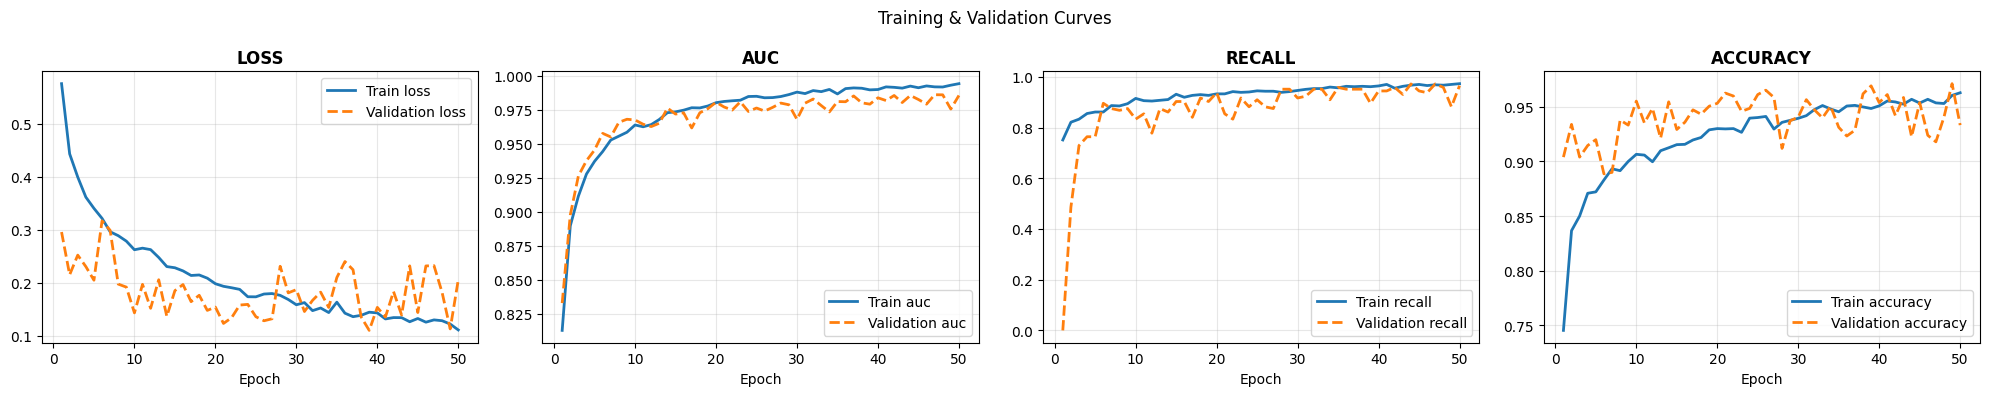

In [16]:
def plot_history(history, metrics=("loss", "auc", "recall", "accuracy")):
    n = len(metrics)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    epochs = range(1, len(history.history["loss"]) + 1)

    for ax, metric in zip(axes, metrics):
        ax.plot(epochs, history.history[metric], label=f"Train {metric}", linewidth=2)
        ax.plot(epochs, history.history[f"val_{metric}"], label=f"Validation {metric}", linewidth=2, linestyle="--")
        ax.set_title(metric.upper(), fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle("Training & Validation Curves")
    plt.tight_layout()
    plt.show()

plot_history(history)

## Evaluation on Test Set

We now evaluate the model on the **test set**. Unseen data.

In [17]:
# Get predicted probabilities
y_prob = model.predict(X_test, verbose=0).ravel()

# Default threshold = 0.5
y_pred_default = (y_prob >= 0.5).astype(int)

auc  = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"AUC: {auc}")
print(f"PR AUC: {pr_auc}")
print(classification_report(y_test, y_pred_default, target_names=["normal", "spiderman"]))

AUC: 0.9822547935103245
PR AUC: 0.9378584602102579
              precision    recall  f1-score   support

      normal       1.00      0.92      0.96      1356
   spiderman       0.57      0.96      0.71       144

    accuracy                           0.93      1500
   macro avg       0.78      0.94      0.84      1500
weighted avg       0.95      0.93      0.93      1500



### Confusion Matrix

The confusion matrix shows the four types of predictions:
- **True Negatives (TN)**: correctly classified as normal  
- **False Positives (FP)**: normal skin wrongly flagged → minor inconvenience  
- **False Negatives (FN)**: flagged skin missed → ⚠️ the error we most want to minimize  
- **True Positives (TP)**: correctly detected flagged skin

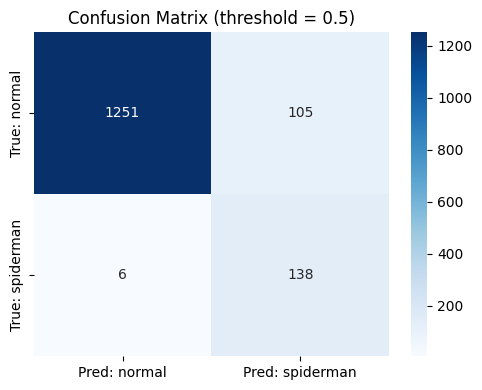

True Negatives (correct normal) : 1251
False Positives (normal→flagged): 105 -> recoverable error
False Negatives (flagged→normal): 6 -> critical error
True Positives (correct flagged): 138


In [18]:
cm = confusion_matrix(y_test, y_pred_default)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: normal", "Pred: spiderman"],
    yticklabels=["True: normal", "True: spiderman"],
    ax=ax
)
ax.set_title("Confusion Matrix (threshold = 0.5)", fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correct normal) : {tn}")
print(f"False Positives (normal→flagged): {fp} -> recoverable error")
print(f"False Negatives (flagged→normal): {fn} -> critical error")
print(f"True Positives (correct flagged): {tp}")

## ROC- and Precision/Recall-Curve

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

prec, rec, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

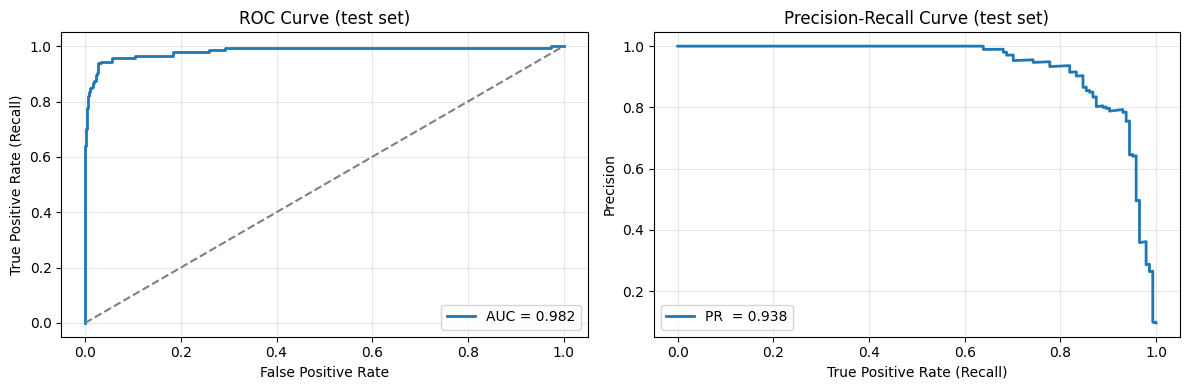

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve (test set)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(rec, prec, linewidth=2, label=f"PR  = {pr_auc:.3f}")
axes[1].set_xlabel("True Positive Rate (Recall)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (test set)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Metrics used
**True Positive Rate (Recall)**: (Recall, Sensitivity)
$$Recall = \text{TPR} = \frac{TP}{TP + FN}$$
> Of all actually flagged spiderman skins, how many did we predict?

**False Positive Rate**:
$$\text{FPR} = \frac{FP}{FP + TN}$$
> Of all actually normal skins, how many did we wrongly flag as spiderman?

**Precision**:
$$\text{Precision} = \frac{TP}{TP + FP}$$
> Of all skins we flagged, how many were truly bad?.

Both curves show classifier behaviour across all thresholds, not just $0.5$.

- ROC plots TPR vs FPR. Standard view, but FPR has $FP + TN$ in the denominator, dominated by the 9000 normal skins. Many false positives barely shift the curve, so it looks too optimistic!

- PR plots Precision vs Recall, actually the tradeoff we follow with our research question. Precision $\frac{TP}{TP+FP}$ ignores $TN$, so the $9{:}1$ imbalance does not hide errors. Answers what matters here: of all skins we flag, how many are really spiderman?

For our imbalanced, recall-focused problem PR-AUC (Average Precision) is the more meaningful summary than ROC-AUC.

## Threshold Tuning

The default decision threshold of **0.5** is not always optimal, especially when one error type is more costly than the other.
Therefore we track evaulation metrics over possible thresholds and look for the (idx) max. threshold that reaches our recall target.

In [21]:
# use the validation set (not the test set!) to figure out the max. threshold that allows approx. 95% of recall (5% false negatives) in deployment.
y_prob_val = model.predict(X_val, verbose=0).ravel()

thresholds = np.linspace(0.05, 0.95, 200)
results = []
for t in thresholds:
    y_hat = (y_prob_val >= t).astype(int) # prediction
    rec = ((y_hat == 1) & (y_val == 1)).sum() / max((y_val == 1).sum(), 1)
    pre = ((y_hat == 1) & (y_val == 1)).sum() / max((y_hat == 1).sum(), 1)
    f1  = f1_score(y_val, y_hat, zero_division=0)
    results.append({"threshold": t, "recall": rec, "precision": pre, "f1": f1, })

results_df = pd.DataFrame(results)

# pick the strictest (highest) threshold that still hits the recall target
eligible = results_df[results_df["recall"] >= RECALL_TARGET]
if eligible.empty:
    raise ValueError(f"No threshold reaches recall ≥ {RECALL_TARGET} on the validation set.")
best_row = eligible.loc[eligible["threshold"].idxmax()]
BEST_THRESH = best_row["threshold"]

print(f"Recall target: ≥ {RECALL_TARGET}")
print(f"Chosen threshold: {BEST_THRESH:.4f}")
print(f"Recall: {best_row['recall']:.4f}")
print(f"precision: {best_row['precision']:.4f}")
print(f"F1: {best_row['f1']:.4f}")

Recall target: ≥ 0.95
Chosen threshold: 0.7601
Recall: 0.9514
precision: 0.6432
F1: 0.7675


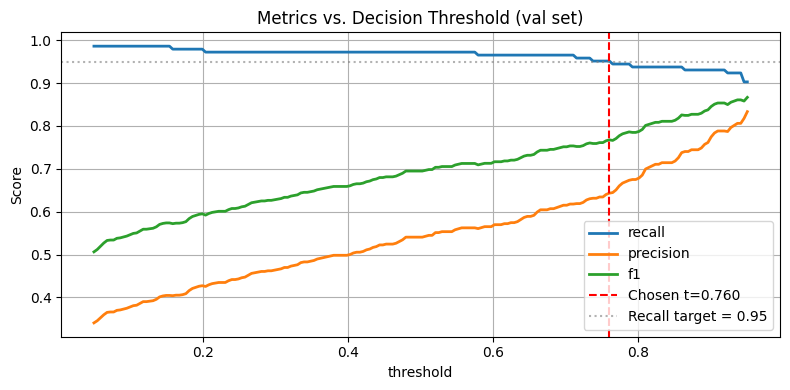

In [22]:
ax = results_df.set_index("threshold")[["recall", "precision", "f1"]].plot(
    figsize=(8, 4), linewidth=2, grid=True
)
ax.axvline(BEST_THRESH, color="red", linestyle="--", label=f"Chosen t={BEST_THRESH:.3f}")
ax.axhline(RECALL_TARGET, color="gray", linestyle=":", alpha=0.6, label=f"Recall target = {RECALL_TARGET}")
ax.set_title("Metrics vs. Decision Threshold (val set)")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

Final Test Evaluation (threshold = 0.7600502512562815)
              precision    recall  f1-score   support

      normal       0.99      0.96      0.98      1356
     flagged       0.71      0.94      0.81       144

    accuracy                           0.96      1500
   macro avg       0.85      0.95      0.89      1500
weighted avg       0.97      0.96      0.96      1500



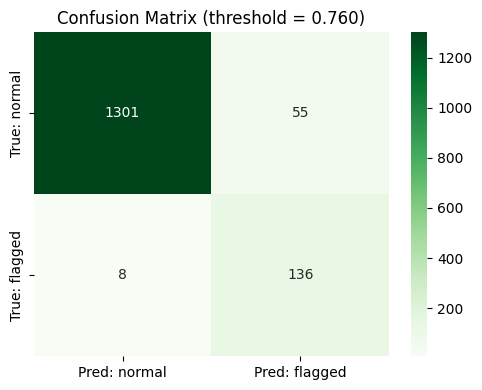

In [23]:
# Final evaluation on TEST set with tuned threshold
y_pred_tuned = (y_prob >= BEST_THRESH).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f"Final Test Evaluation (threshold = {BEST_THRESH})")
print(classification_report(y_test, y_pred_tuned, target_names=["normal", "flagged"]))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_tuned, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Pred: normal", "Pred: flagged"],
    yticklabels=["True: normal", "True: flagged"],
    ax=ax
)
ax.set_title(f"Confusion Matrix (threshold = {BEST_THRESH:.3f})", fontsize=12)
plt.tight_layout()
plt.show()

## Error Analysis

Visualizing and printing the false predictions of the Training/Val sets. This helps us understand where it struggles and how it could be improved in a next iteration.

=== TRAIN (7000 samples, threshold=0.76) ===
  Total FN: 3
  Total FP: 241



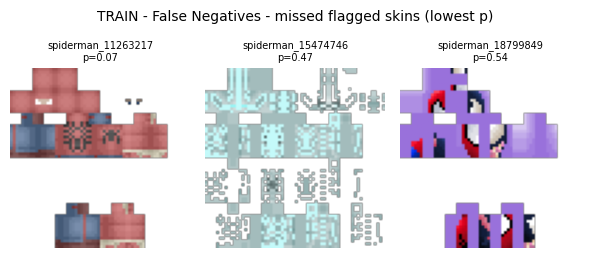


TRAIN - False Negatives - missed flagged skins (lowest p) - full paths:
  p=0.074  ../data/skins/bad/spiderman_cleaned/spiderman_11263217.png
  p=0.474  ../data/skins/bad/spiderman_cleaned/spiderman_15474746.png
  p=0.538  ../data/skins/bad/spiderman_cleaned/spiderman_18799849.png



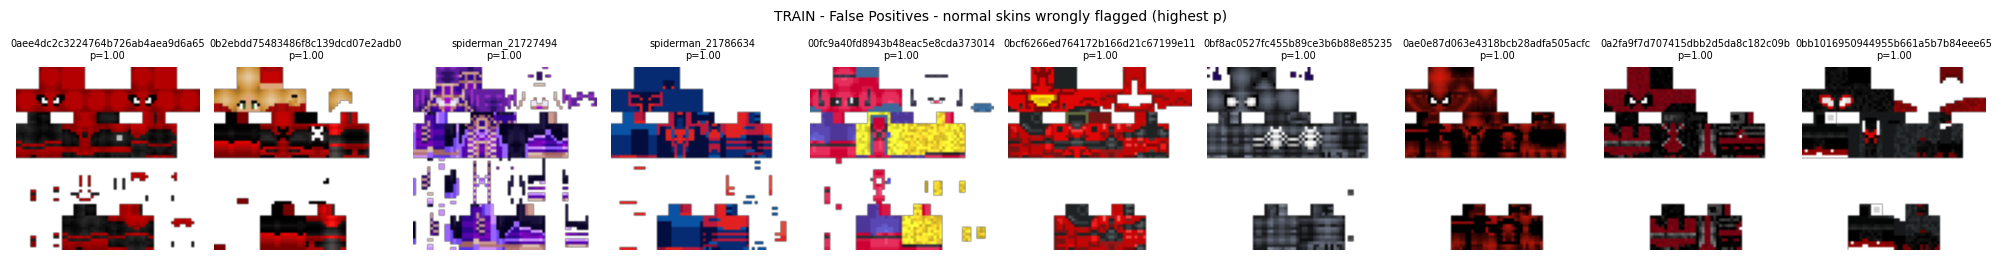


TRAIN - False Positives - normal skins wrongly flagged (highest p) - full paths:
  p=1.000  ../data/skins/good_cleaned/0aee4dc2c3224764b726ab4aea9d6a65.png
  p=1.000  ../data/skins/good_cleaned/0b2ebdd75483486f8c139dcd07e2adb0.png
  p=1.000  ../data/skins/good_cleaned/spiderman_21727494.png
  p=1.000  ../data/skins/good_cleaned/spiderman_21786634.png
  p=0.999  ../data/skins/good_cleaned/00fc9a40fd8943b48eac5e8cda373014.png
  p=0.999  ../data/skins/good_cleaned/0bcf6266ed764172b166d21c67199e11.png
  p=0.999  ../data/skins/good_cleaned/0bf8ac0527fc455b89ce3b6b88e85235.png
  p=0.999  ../data/skins/good_cleaned/0ae0e87d063e4318bcb28adfa505acfc.png
  p=0.998  ../data/skins/good_cleaned/0a2fa9f7d707415dbb2d5da8c182c09b.png
  p=0.998  ../data/skins/good_cleaned/0bb1016950944955b661a5b7b84eee65.png

=== VAL (1500 samples, threshold=0.76) ===
  Total FN: 7
  Total FP: 76



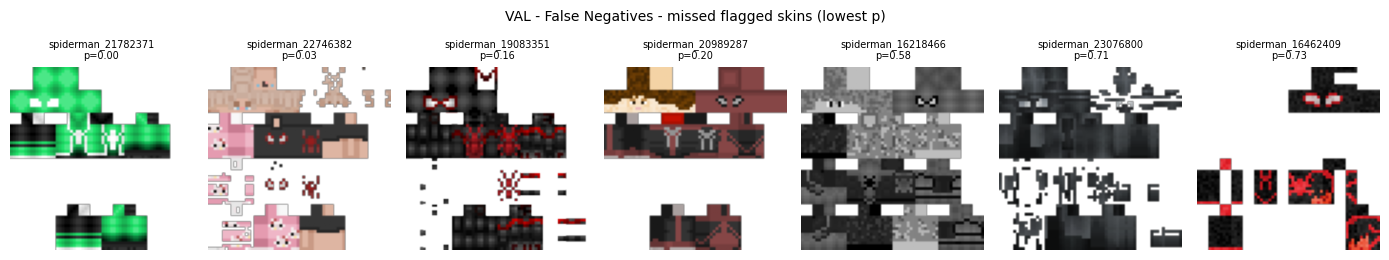


VAL - False Negatives - missed flagged skins (lowest p) - full paths:
  p=0.001  ../data/skins/bad/spiderman_cleaned/spiderman_21782371.png
  p=0.030  ../data/skins/bad/spiderman_cleaned/spiderman_22746382.png
  p=0.158  ../data/skins/bad/spiderman_cleaned/spiderman_19083351.png
  p=0.201  ../data/skins/bad/spiderman_cleaned/spiderman_20989287.png
  p=0.579  ../data/skins/bad/spiderman_cleaned/spiderman_16218466.png
  p=0.714  ../data/skins/bad/spiderman_cleaned/spiderman_23076800.png
  p=0.733  ../data/skins/bad/spiderman_cleaned/spiderman_16462409.png



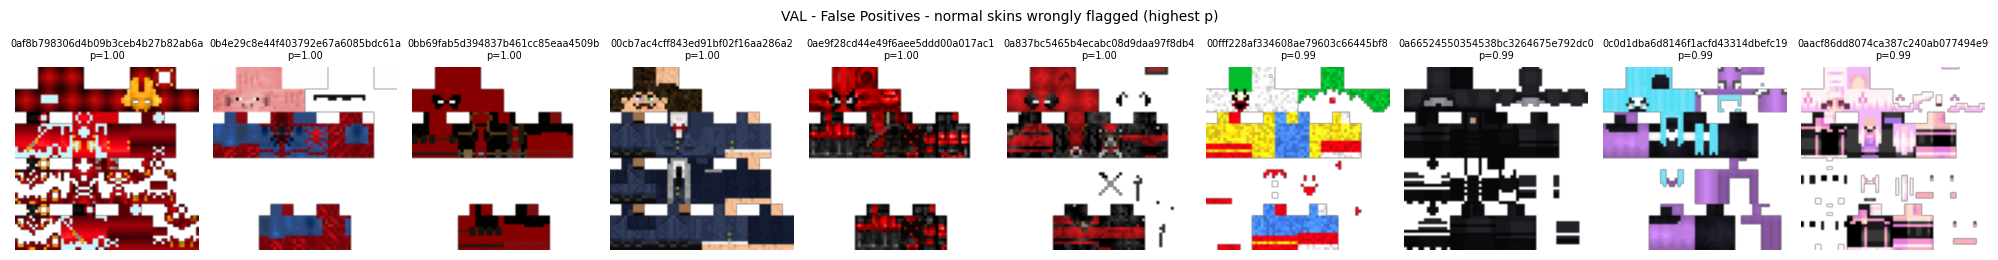


VAL - False Positives - normal skins wrongly flagged (highest p) - full paths:
  p=1.000  ../data/skins/good_cleaned/0af8b798306d4b09b3ceb4b27b82ab6a.png
  p=0.998  ../data/skins/good_cleaned/0b4e29c8e44f403792e67a6085bdc61a.png
  p=0.997  ../data/skins/good_cleaned/0bb69fab5d394837b461cc85eaa4509b.png
  p=0.997  ../data/skins/good_cleaned/00cb7ac4cff843ed91bf02f16aa286a2.png
  p=0.997  ../data/skins/good_cleaned/0ae9f28cd44e49f6aee5ddd00a017ac1.png
  p=0.996  ../data/skins/good_cleaned/0a837bc5465b4ecabc08d9daa97f8db4.png
  p=0.994  ../data/skins/good_cleaned/00fff228af334608ae79603c66445bf8.png
  p=0.993  ../data/skins/good_cleaned/0a66524550354538bc3264675e792dc0.png
  p=0.990  ../data/skins/good_cleaned/0c0d1dba6d8146f1acfd43314dbefc19.png
  p=0.987  ../data/skins/good_cleaned/0aacf86dd8074ca387c240ab077494e9.png



In [24]:
def error_analysis(X, y, paths, threshold, model, split_name, N=10):
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    y_true = y.astype(int)

    fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]
    fn_idx = fn_idx[np.argsort(y_prob[fn_idx])][:N]

    fp_idx = np.where((y_true == 0) & (y_pred == 1))[0]
    fp_idx = fp_idx[np.argsort(-y_prob[fp_idx])][:N]

    print(f"=== {split_name} ({len(X)} samples, threshold={threshold:.2f}) ===")
    print(f"  Total FN: {((y_true == 1) & (y_pred == 0)).sum()}")
    print(f"  Total FP: {((y_true == 0) & (y_pred == 1)).sum()}\n")

    for title, idx in [(f"{split_name} - False Negatives - missed flagged skins (lowest p)", fn_idx),
                       (f"{split_name} - False Positives - normal skins wrongly flagged (highest p)", fp_idx)]:
        if len(idx) == 0:
            print(f"No errors for: {title}")
            continue

        fig, axes = plt.subplots(1, len(idx), figsize=(2 * len(idx), 2.8))
        fig.suptitle(title, fontsize=10)
        for ax, i in zip(np.atleast_1d(axes), idx):
            p = Path(paths[i])
            ax.imshow(X[i, :, :, :4])
            ax.set_title(f"{p.stem}\np={y_prob[i]:.2f}", fontsize=7)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

        print(f"\n{title} - full paths:")
        for i in idx:
            print(f"  p={y_prob[i]:.3f}  {paths[i]}")
        print()


# Run on train and val only - test stays untouched
error_analysis(X_train, y_train, paths_train, BEST_THRESH, model, "TRAIN")
error_analysis(X_val,   y_val,   paths_val,   BEST_THRESH, model, "VAL")

An earlier run with an uncleaned dataset showed us this:
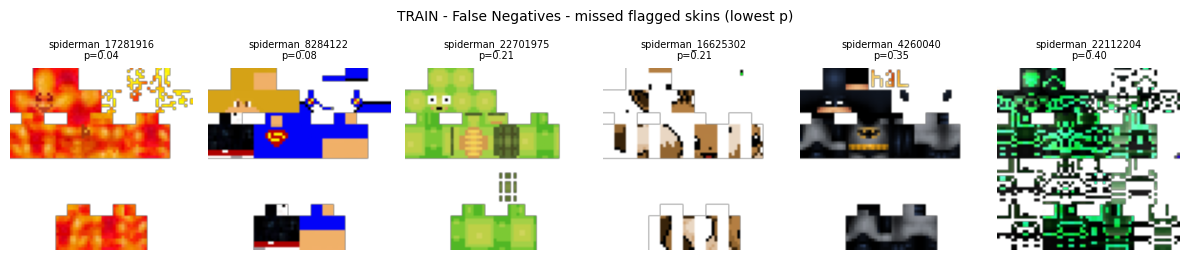

batman != spiderman != superman -> the spiderman class has clearly wrong skins in it
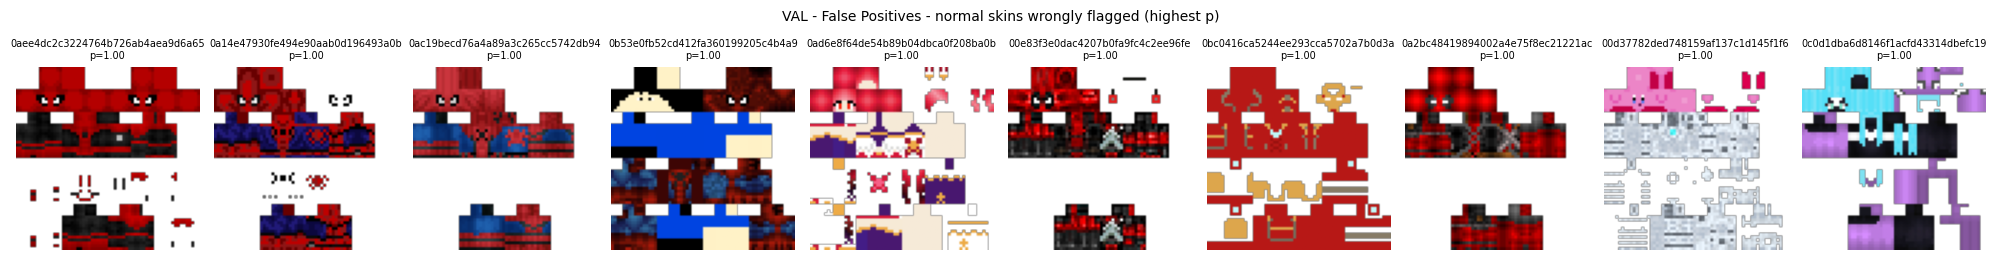

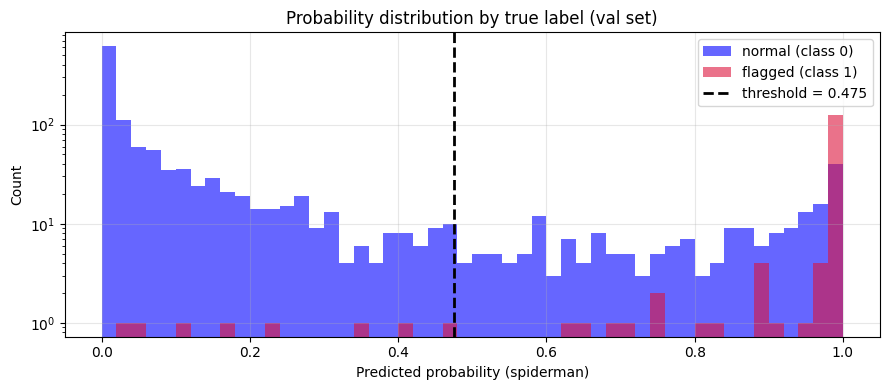

**There were some spidermen inside the normal data set and some non-spidermen inside the spiderman set. Swapping the labels and retraining will show that the models precision will improve**

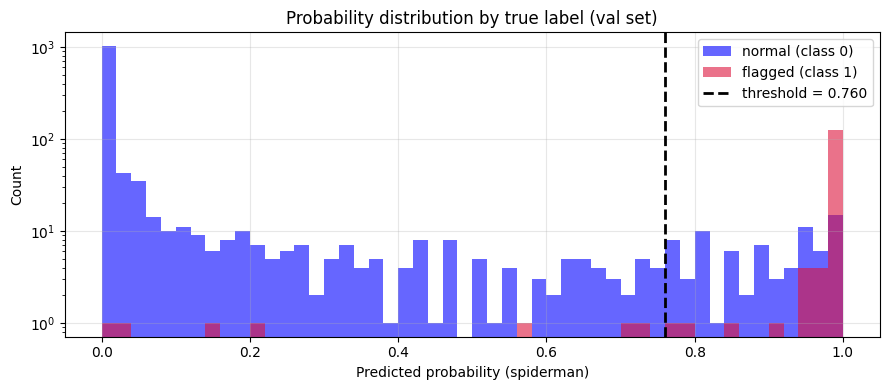

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(y_prob_val[y_val == 0], bins=50, range=(0, 1),alpha=0.6, label="normal (class 0)", color="blue")
ax.hist(y_prob_val[y_val == 1], bins=50, range=(0, 1),alpha=0.6, label="flagged (class 1)", color="crimson")

ax.axvline(BEST_THRESH, color="black", linestyle="--", linewidth=2, label=f"threshold = {BEST_THRESH:.3f}")

ax.set_xlabel("Predicted probability (spiderman)")
ax.set_ylabel("Count")
ax.set_title("Probability distribution by true label (val set)")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()





### Limitations & future work


In [26]:
# Save the final model
model.save(str(MODEL_PATH) + "_10k_wednesday" + ".keras")
print(f"Model saved to: {MODEL_PATH}")

Model saved to: ../04_Modeling/checkpoint.keras


---
## Results and Learnings
can be found in `Modeling_Results.ipynb`

In [27]:
from tensorflow.keras.models import load_model
import os
print(os.getcwd())
print(os.listdir())
print((str(MODEL_PATH) + "_10k_wednesday" + ".keras"))
model_tmp = load_model(str(MODEL_PATH) + "_10k_wednesday" + ".keras")
#model = load_model(str(MODEL_PATH))
#print(f"Model loaded from: {MODEL_PATH}")

/Users/markus/Documents/Master AI/Machine Learning/Project/ML_Project/04_Modelling
['cnn-for-mnist-classification.ipynb', 'Modeling.ipynb', 'Modeling_Results.ipynb', 'cnn_mvp.ipynb', '.ipynb_checkpoints']
../04_Modeling/checkpoint.keras_10k_wednesday.keras


Using Conv Layer: conv2d_5


/opt/anaconda3/envs/ml-puch/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 64, 64, 4))
  warnings.warn(msg)


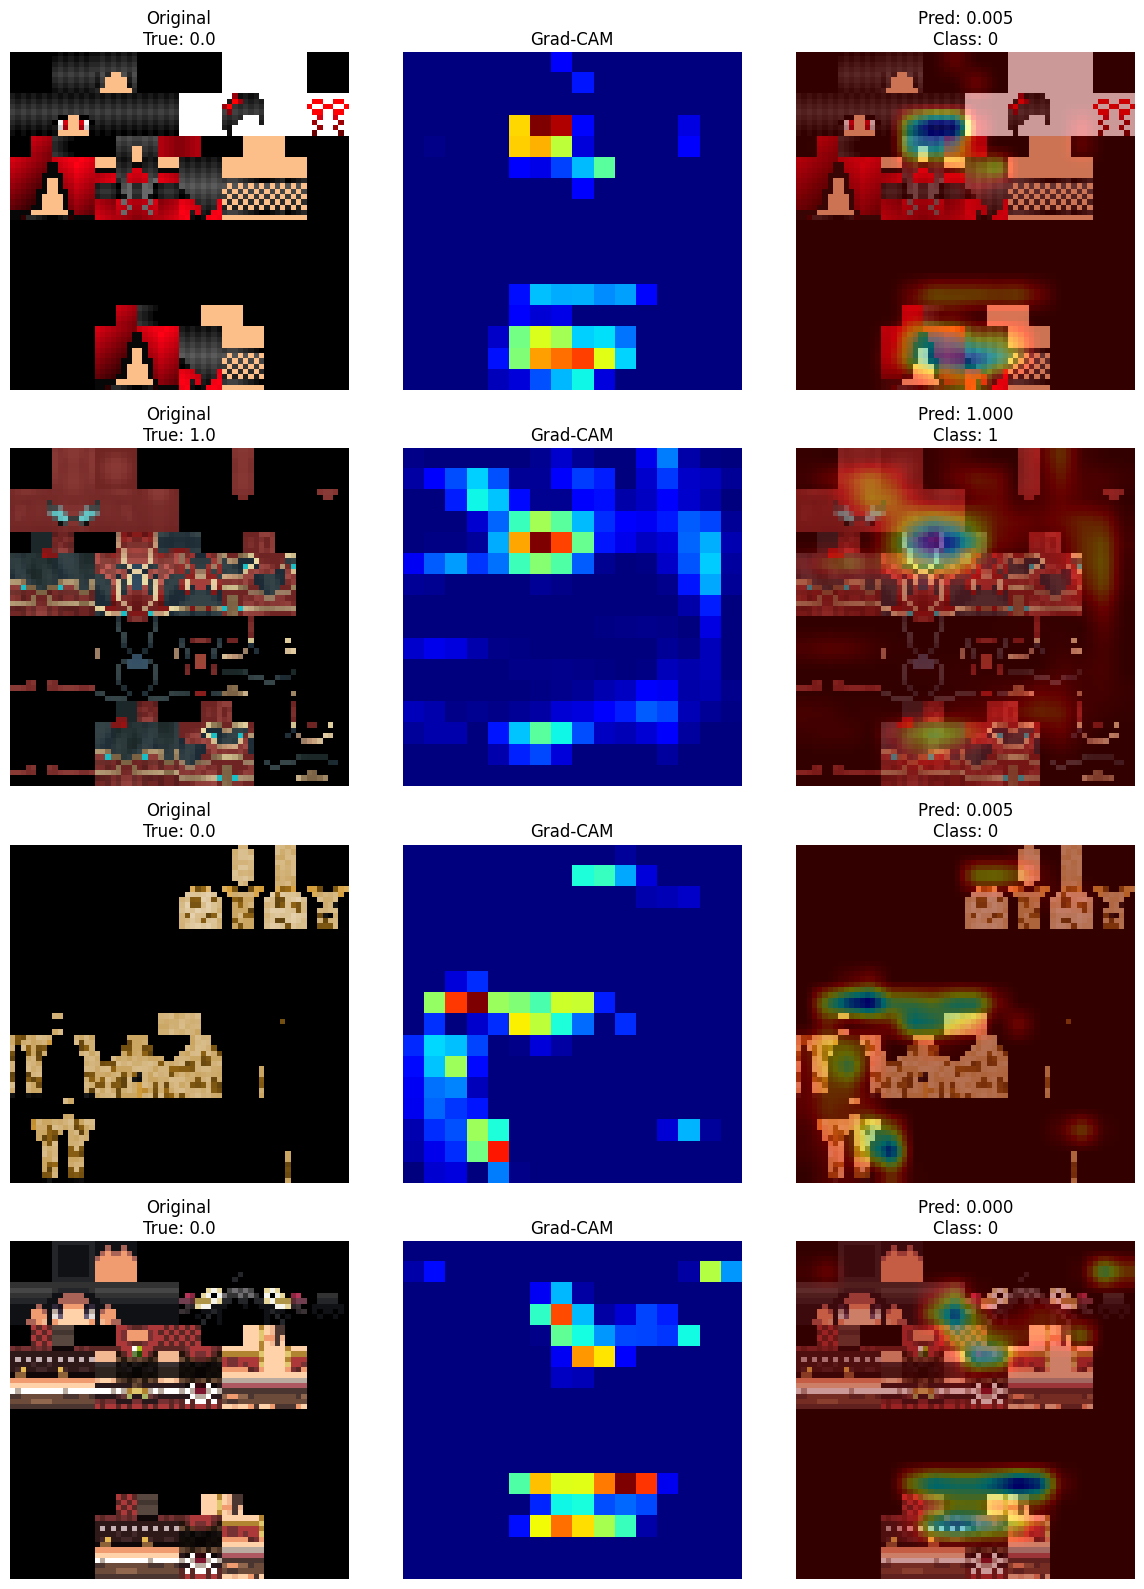

In [28]:
## GradCam

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2


# =============================================================================
# FORCE MODEL BUILD
# =============================================================================

_ = model.predict(
    np.zeros((1, IMG_SIZE[0], IMG_SIZE[1], N_CHANNELS)),
    verbose=0
)


# =============================================================================
# AUTOMATICALLY FIND LAST CONV LAYER
# =============================================================================

LAST_CONV_LAYER = None

for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        LAST_CONV_LAYER = layer.name
        break

print("Using Conv Layer:", LAST_CONV_LAYER)


# =============================================================================
# GRAD-CAM
# =============================================================================

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # target conv layer
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # IMPORTANT:
    # create functional submodels explicitly

    conv_model = tf.keras.Model(
        model.inputs,
        last_conv_layer.output
    )

    classifier_input = tf.keras.Input(
        shape=last_conv_layer.output.shape[1:]
    )

    x = classifier_input

    found = False

    for layer in model.layers:

        if layer.name == last_conv_layer_name:
            found = True
            continue

        if found:
            x = layer(x)

    classifier_model = tf.keras.Model(
        classifier_input,
        x
    )

    # gradient computation
    with tf.GradientTape() as tape:

        conv_outputs = conv_model(
            img_array,
            training=False
        )

        tape.watch(conv_outputs)

        predictions = classifier_model(
            conv_outputs,
            training=False
        )

        loss = predictions[:, 0] # binary only

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()


# =============================================================================
# OVERLAY
# =============================================================================

def overlay_heatmap(heatmap, image, alpha=0.4):

    heatmap = cv2.resize(
        heatmap,
        (image.shape[1], image.shape[0])
    )

    heatmap_uint8 = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    # RGBA -> RGB
    if image.shape[-1] == 4:
        image_rgb = image[:, :, :3]
    else:
        image_rgb = image

    if image_rgb.max() <= 1.0:
        image_rgb = (
            image_rgb * 255
        ).astype(np.uint8)

    overlay = cv2.addWeighted(
        image_rgb,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    return overlay


# =============================================================================
# VISUALIZATION
# =============================================================================

def visualize_gradcam_examples(
    model,
    X,
    y,
    indices,
    layer_name
):

    n = len(indices)

    fig, axes = plt.subplots(
        n,
        3,
        figsize=(12, 4 * n)
    )

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):

        img = X[idx]

        input_img = np.expand_dims(img, axis=0)

        pred = model.predict(
            input_img,
            verbose=0
        )[0][0]

        pred_class = int(pred > 0.5)

        heatmap = make_gradcam_heatmap(
            input_img,
            model,
            layer_name
        )

        overlay = overlay_heatmap(
            heatmap,
            img
        )

        # ORIGINAL
        axes[row, 0].imshow(img[:, :, :3])
        axes[row, 0].set_title(
            f"Original\nTrue: {y[idx]}"
        )
        axes[row, 0].axis("off")

        # HEATMAP
        axes[row, 1].imshow(
            heatmap,
            cmap="jet"
        )
        axes[row, 1].set_title(
            "Grad-CAM"
        )
        axes[row, 1].axis("off")

        # OVERLAY
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(
            f"Pred: {pred:.3f}\nClass: {pred_class}"
        )
        axes[row, 2].axis("off")

    plt.tight_layout()
    plt.show()


# =============================================================================
# RUN
# =============================================================================

example_indices = [0, 5, 12, 27]

visualize_gradcam_examples(
    model=model,
    X=X_test,
    y=y_test,
    indices=example_indices,
    layer_name=LAST_CONV_LAYER
)

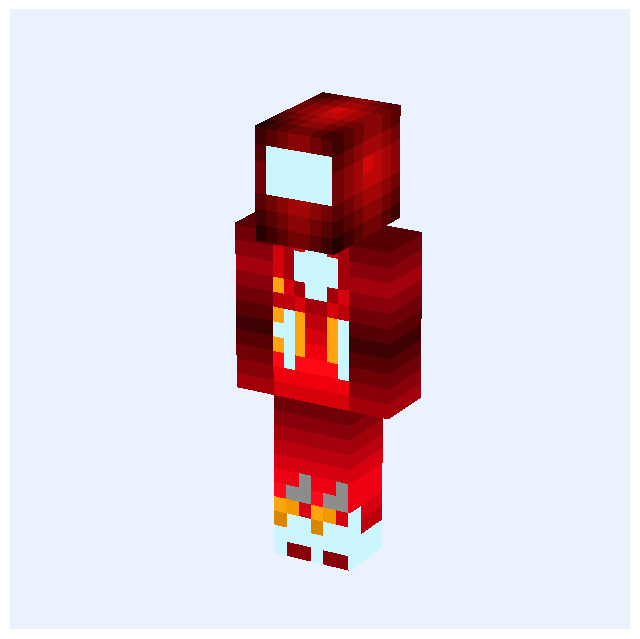

In [29]:
## Animation Version Figur stehend no Overlay Layer

"""
Minecraft Skin Viewer mit echten Pixeltexturen
================================================

Features:
- echte Minecraft-Skin-Texturen
- 64x64 Skin Support
- rotierbare 3D-Figur
- Pixel-Look
- Animation
- matplotlib only

Installation:
    pip install pillow matplotlib numpy

Start:
    python skin_viewer_textured.py skin.png
"""

import sys
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


# ============================================================
# Skin laden
# ============================================================

if len(sys.argv) < 2:
    print("Usage: python skin_viewer_textured.py skin.png")
    sys.exit(1)

skin_path = "../data/skins/good_cleaned/0af8b798306d4b09b3ceb4b27b82ab6a.png" # sys.argv[1]

skin = Image.open(skin_path).convert("RGBA")
skin = np.array(skin) / 255.0


# ============================================================
# UV Helper
# ============================================================

def tex(x, y, w, h):
    """
    Minecraft UV Bereich ausschneiden.
    Flip wegen matplotlib Orientierung.
    """
    t = skin[y:y+h, x:x+w]
    return np.flipud(t)


# ============================================================
# Minecraft UV Mapping
# ============================================================

HEAD = {
    "front": tex(8, 8, 8, 8),
    "back": tex(24, 8, 8, 8),
    "left": tex(16, 8, 8, 8),
    "right": tex(0, 8, 8, 8),
    "top": tex(8, 0, 8, 8),
    "bottom": tex(16, 0, 8, 8),
}

BODY = {
    "front": tex(20, 20, 8, 12),
    "back": tex(32, 20, 8, 12),
    "left": tex(28, 20, 4, 12),
    "right": tex(16, 20, 4, 12),
    "top": tex(20, 16, 8, 4),
    "bottom": tex(28, 16, 8, 4),
}

ARM = {
    "front": tex(44, 20, 4, 12),
    "back": tex(52, 20, 4, 12),
    "left": tex(48, 20, 4, 12),
    "right": tex(40, 20, 4, 12),
    "top": tex(44, 16, 4, 4),
    "bottom": tex(48, 16, 4, 4),
}

LEG = {
    "front": tex(4, 20, 4, 12),
    "back": tex(12, 20, 4, 12),
    "left": tex(8, 20, 4, 12),
    "right": tex(0, 20, 4, 12),
    "top": tex(4, 16, 4, 4),
    "bottom": tex(8, 16, 4, 4),
}


# ============================================================
# Texturierte Fläche
# ============================================================

def draw_face(ax, X, Y, Z, texture):
    """
    Zeichnet eine texturierte Fläche.
    """

    ax.plot_surface(
        X,
        Z,
        Y,
        rstride=1,
        cstride=1,
        facecolors=texture,
        shade=False,
        antialiased=False
    )


# ============================================================
# Würfel mit echten Texturen
# ============================================================

def draw_cube(ax, origin, size, texmap):

    ox, oy, oz = origin
    sx, sy, sz = size

    # --------------------------------------------------------
    # FRONT
    # --------------------------------------------------------
    t = texmap["front"]

    x = np.linspace(ox, ox+sx, t.shape[1])
    y = np.linspace(oy, oy+sy, t.shape[0])

    X, Y = np.meshgrid(x, y)
    Z = np.full_like(X, oz)

    draw_face(ax, X, Y, Z, t)

    # --------------------------------------------------------
    # BACK
    # --------------------------------------------------------
    t = texmap["back"]

    x = np.linspace(ox+sx, ox, t.shape[1])
    y = np.linspace(oy, oy+sy, t.shape[0])

    X, Y = np.meshgrid(x, y)
    Z = np.full_like(X, oz+sz)

    draw_face(ax, X, Y, Z, t)

    # --------------------------------------------------------
    # LEFT
    # --------------------------------------------------------
    t = texmap["left"]

    z = np.linspace(oz+sz, oz, t.shape[1])
    y = np.linspace(oy, oy+sy, t.shape[0])

    Z, Y = np.meshgrid(z, y)
    X = np.full_like(Z, ox)

    draw_face(ax, X, Y, Z, t)

    # --------------------------------------------------------
    # RIGHT
    # --------------------------------------------------------
    t = texmap["right"]

    z = np.linspace(oz, oz+sz, t.shape[1])
    y = np.linspace(oy, oy+sy, t.shape[0])

    Z, Y = np.meshgrid(z, y)
    X = np.full_like(Z, ox+sx)

    draw_face(ax, X, Y, Z, t)

    # --------------------------------------------------------
    # TOP
    # --------------------------------------------------------
    t = texmap["top"]

    x = np.linspace(ox, ox+sx, t.shape[1])
    z = np.linspace(oz, oz+sz, t.shape[0])

    X, Z = np.meshgrid(x, z)
    Y = np.full_like(X, oy+sy)

    draw_face(ax, X, Y, Z, t)

    # --------------------------------------------------------
    # BOTTOM
    # --------------------------------------------------------
    t = texmap["bottom"]

    x = np.linspace(ox, ox+sx, t.shape[1])
    z = np.linspace(oz+sz, oz, t.shape[0])

    X, Z = np.meshgrid(x, z)
    Y = np.full_like(X, oy)

    draw_face(ax, X, Y, Z, t)


# ============================================================
# Plot Setup
# ============================================================

fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(111, projection='3d')

# Kamera
ax.view_init(elev=20, azim=-60)

# bessere Proportionen
ax.set_box_aspect([1, 2, 1])

ax.set_facecolor((0.92, 0.95, 1.0))

# ============================================================
# Figur
# ============================================================

# Kopf
draw_cube(ax, (2, 12, 2), (4,4,4), HEAD)

# Körper
draw_cube(ax, (2, 6, 3), (4,6,2), BODY)

# Arme
draw_cube(ax, (0, 6, 3), (2,6,2), ARM)
draw_cube(ax, (6, 6, 3), (2,6,2), ARM)

# Beine
draw_cube(ax, (2, 0, 3), (2,6,2), LEG)
draw_cube(ax, (4, 0, 3), (2,6,2), LEG)

# ============================================================
# Kamera
# ============================================================

ax.set_xlim(-2, 10)
ax.set_ylim(0, 8)
ax.set_zlim(0, 18)

ax.set_box_aspect([1, 1, 2])

ax.axis("off")


# ============================================================
# Rotation Animation
# ============================================================

def update(frame):
    ax.view_init(
        elev=15, # was 20
        azim=frame
    )
    return fig,


ani = FuncAnimation(
    fig,
    update,
    frames=np.arange(0, 360, 2),
    interval=40,
    blit=False
)

plt.show()

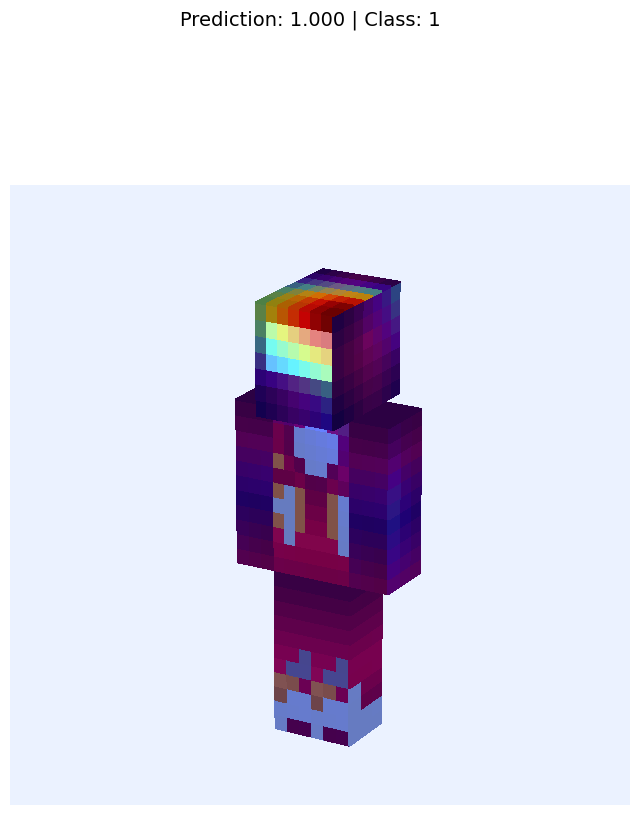

In [30]:
## Das ziel, grad cam + stehend orig
"""
Minecraft Skin Grad-CAM Viewer
==============================

Features
--------
- CNN Grad-CAM für Minecraft Skins
- echte Minecraft UV-Texturen
- 3D Minecraft Figur
- Heatmap direkt auf der Figur
- Rotation Animation
- RGBA Support

Benötigt:
----------
pip install tensorflow matplotlib pillow opencv-python numpy

Usage:
------
python gradcam_skin_viewer.py skin.png
"""

skin_path = "../data/skins/good_cleaned/0af8b798306d4b09b3ceb4b27b82ab6a.png"
skin_pil = Image.open(skin_path).convert("RGBA")
skin = np.array(skin_pil) / 255.0
input_img = np.expand_dims(skin, axis=0)

# =============================================================================
# APPLY HEATMAP TO FULL SKIN
# =============================================================================

def apply_heatmap_to_skin(
    skin,
    heatmap,
    alpha=0.5
):

    heatmap = cv2.resize(
        heatmap,
        (skin.shape[1], skin.shape[0]),
        interpolation=cv2.INTER_NEAREST # tip
    )

    heatmap_uint8 = np.uint8(
        255 * heatmap
    )

    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = (
        heatmap_color[:, :, ::-1] / 255.0
    )

    rgb = skin[:, :, :3]

    overlay = (
        (1 - alpha) * rgb
        + alpha * heatmap_color
    )

    result = skin.copy()

    result[:, :, :3] = overlay

    return result


# =============================================================================
# CREATE HEATMAP
# =============================================================================

heatmap = make_gradcam_heatmap(
    input_img,
    model,
    LAST_CONV_LAYER
)

skin_gradcam = apply_heatmap_to_skin(
    skin,
    heatmap,
    alpha=0.5
)


# =============================================================================
# UV HELPER
# =============================================================================

def tex(skin_data, x, y, w, h):

    t = skin_data[y:y+h, x:x+w]

    return np.flipud(t)


# =============================================================================
# UV MAPPING
# =============================================================================

HEAD = {
    "front": tex(skin_gradcam, 8, 8, 8, 8),
    "back": tex(skin_gradcam, 24, 8, 8, 8),
    "left": tex(skin_gradcam, 16, 8, 8, 8),
    "right": tex(skin_gradcam, 0, 8, 8, 8),
    "top": tex(skin_gradcam, 8, 0, 8, 8),
    "bottom": tex(skin_gradcam, 16, 0, 8, 8),
}

BODY = {
    "front": tex(skin_gradcam, 20, 20, 8, 12),
    "back": tex(skin_gradcam, 32, 20, 8, 12),
    "left": tex(skin_gradcam, 28, 20, 4, 12),
    "right": tex(skin_gradcam, 16, 20, 4, 12),
    "top": tex(skin_gradcam, 20, 16, 8, 4),
    "bottom": tex(skin_gradcam, 28, 16, 8, 4),
}

ARM = {
    "front": tex(skin_gradcam, 44, 20, 4, 12),
    "back": tex(skin_gradcam, 52, 20, 4, 12),
    "left": tex(skin_gradcam, 48, 20, 4, 12),
    "right": tex(skin_gradcam, 40, 20, 4, 12),
    "top": tex(skin_gradcam, 44, 16, 4, 4),
    "bottom": tex(skin_gradcam, 48, 16, 4, 4),
}

LEG = {
    "front": tex(skin_gradcam, 4, 20, 4, 12),
    "back": tex(skin_gradcam, 12, 20, 4, 12),
    "left": tex(skin_gradcam, 8, 20, 4, 12),
    "right": tex(skin_gradcam, 0, 20, 4, 12),
    "top": tex(skin_gradcam, 4, 16, 4, 4),
    "bottom": tex(skin_gradcam, 8, 16, 4, 4),
}

# =============================================================================
# PLOT
# =============================================================================

fig = plt.figure(figsize=(8, 10))
ax = fig.add_subplot(
    111,
    projection='3d'
)
ax.view_init(elev=20, azim=-60)
# bessere Proportionen
ax.set_box_aspect([1, 2, 1])

ax.set_facecolor(
    (0.92, 0.95, 1.0)
)


# =============================================================================
# DRAW FIGURE
# =============================================================================

# Kopf
draw_cube(ax, (2, 12, 2), (4,4,4), HEAD)

# Körper
draw_cube(ax, (2, 6, 3), (4,6,2), BODY)

# Arme
draw_cube(ax, (0, 6, 3), (2,6,2), ARM)
draw_cube(ax, (6, 6, 3), (2,6,2), ARM)

# Beine
draw_cube(ax, (2, 0, 3), (2,6,2), LEG)
draw_cube(ax, (4, 0, 3), (2,6,2), LEG)


# =============================================================================
# CAMERA
# =============================================================================

ax.set_xlim(-2, 10)
ax.set_ylim(0, 8)
ax.set_zlim(0, 18)

ax.set_box_aspect([1, 1, 2])

ax.axis("off")


# =============================================================================
# PREDICTION TEXT
# =============================================================================

prediction = model.predict(
    input_img,
    verbose=0
)[0][0]

pred_class = int(prediction > 0.5)

fig.suptitle(
    f"Prediction: {prediction:.3f} | Class: {pred_class}",
    fontsize=14
)


# =============================================================================
# ROTATION ANIMATION
# =============================================================================

def update(frame):

    ax.view_init(
        elev=15,
        azim=frame
    )

    return fig,


ani = FuncAnimation(
    fig,
    update,
    frames=np.arange(0, 360, 2),
    interval=40,
    blit=False
)

plt.show()